# **IMPORT LIBRARY**

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# **LOAD DATASET**

In [25]:
df = pd.read_csv('vgsales.csv')
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


# **EDA (EXPLORATORY DATA ANALYSIS)**

**1. Distribusi Global Sales**

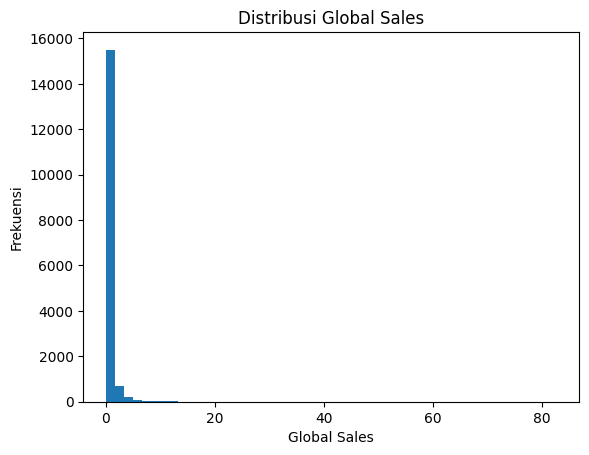

In [26]:
plt.hist(df['Global_Sales'], bins=50)
plt.title("Distribusi Global Sales")
plt.xlabel("Global Sales")
plt.ylabel("Frekuensi")
plt.show()

**2. Korelasi**

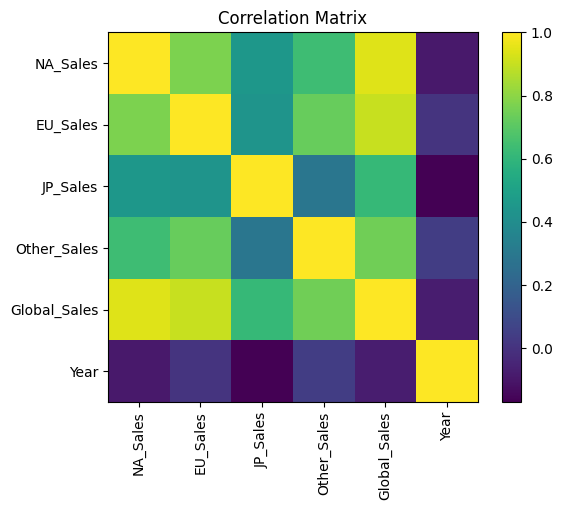

In [27]:
corr = df[['NA_Sales','EU_Sales','JP_Sales','Other_Sales','Global_Sales','Year']].corr()

plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()

**3. Scatter Plot**

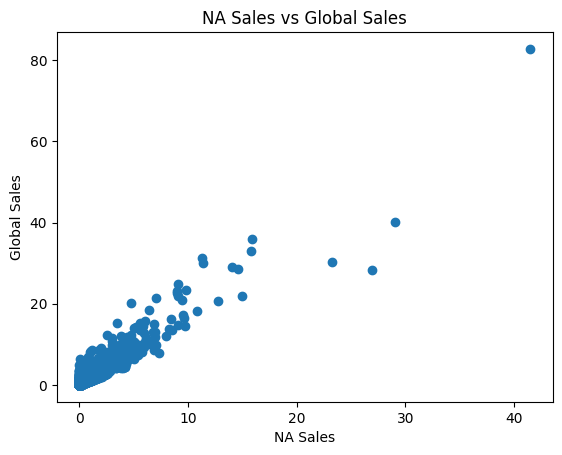

In [28]:
plt.scatter(df['NA_Sales'], df['Global_Sales'])
plt.xlabel("NA Sales")
plt.ylabel("Global Sales")
plt.title("NA Sales vs Global Sales")
plt.show()

# **DATA PREPROCESSING**

**1. Missing Value**

In [29]:
df = df.dropna()

**2. Outlier (IQR)**

In [30]:
def remove_outlier(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] >= lower) & (df[col] <= upper)]

for col in ['NA_Sales','EU_Sales','JP_Sales','Other_Sales','Global_Sales']:
    df = remove_outlier(df, col)

# **FITUR & TARGET**

In [31]:
X = df[['NA_Sales','EU_Sales','JP_Sales','Other_Sales','Year']]
y = df['Global_Sales']

# **DATA SPLITTING**

In [32]:
# 80:20
X_train1, X_test1, y_train1, y_test1 = train_test_split(X, y, test_size=0.2, random_state=42)

# 70:30
X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, test_size=0.3, random_state=42)

# 60:40
X_train3, X_test3, y_train3, y_test3 = train_test_split(X, y, test_size=0.4, random_state=42)

# **MODEL TRAINING + TUNING**

**1. Linear Regression**

In [33]:
lr = LinearRegression()
lr.fit(X_train1, y_train1)
y_pred_lr = lr.predict(X_test1)

**2. Decision Tree**

In [34]:
dt = DecisionTreeRegressor(max_depth=10, min_samples_split=5, random_state=42)
dt.fit(X_train1, y_train1)
y_pred_dt = dt.predict(X_test1)

**3. Random Forest**

In [35]:
rf = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42)
rf.fit(X_train1, y_train1)
y_pred_rf = rf.predict(X_test1)

# **MODEL EVALUTION**

In [36]:
def evaluate(y_test, y_pred):
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    return r2, mae, rmse

r2_lr, mae_lr, rmse_lr = evaluate(y_test1, y_pred_lr)
r2_dt, mae_dt, rmse_dt = evaluate(y_test1, y_pred_dt)
r2_rf, mae_rf, rmse_rf = evaluate(y_test1, y_pred_rf)

**HASIL**

In [37]:
print("Linear Regression:", r2_lr, mae_lr, rmse_lr)
print("Decision Tree:", r2_dt, mae_dt, rmse_dt)
print("Random Forest:", r2_rf, mae_rf, rmse_rf)

Linear Regression: 0.9978400170835473 0.0032477892197122545 0.005034708634653761
Decision Tree: 0.9927452903823446 0.0058605237811185824 0.009226971966567375
Random Forest: 0.9960469116356477 0.004313827907851259 0.006811102961580321


# **VISUALISASI PERBANDINGAN MODEL**

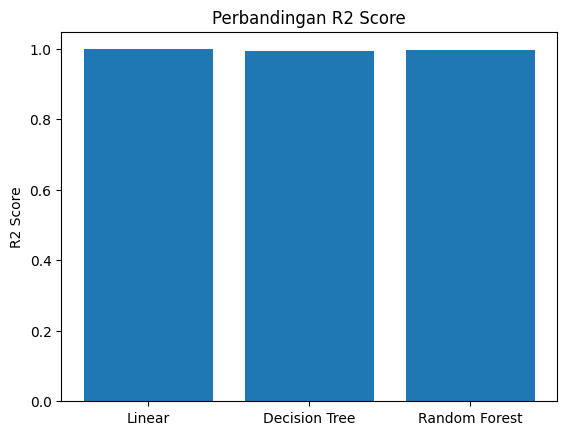

In [38]:
models = ['Linear', 'Decision Tree', 'Random Forest']
scores = [r2_lr, r2_dt, r2_rf]

plt.bar(models, scores)
plt.title("Perbandingan R2 Score")
plt.ylabel("R2 Score")
plt.show()